# 11. 시기 단위 분기: 모델을 언제 쓸 것인가

## Overview

10번에서 시금치가 9월에 유난히 잘 맞는다는 걸 봤습니다. 같은 품목이라도 **시기에
따라 모델이 크게 벌기도 하고 헛발질하기도 합니다.**

그렇다면 **잘 되는 시기에만 모델을 쓰고 나머지는 그냥 두면** 어떨까요.
04번에서 품목 단위로 나누는 건 실패했지만, 시기 단위는 다른 이야기입니다.

## 먼저 용어 하나

이 문서 내내 나오는 말이라 짚고 갑니다.

> **"모델을 쓴 게 이득이었던 날 / 손해였던 날"**

매일, 품목마다 두 가지 답을 채점합니다.

| 답하는 방법 | 내용 |
|---|---|
| **그냥 두기(naive)** | "오늘 가격 그대로일 것이다" |
| **모델** | "이만큼 오르거나 내릴 것이다" |

7거래일 뒤 실제 가격이 나오면 둘 중 누가 덜 틀렸는지 비교합니다.

- **이득인 날**: 모델 답이 실제에 더 가까웠던 날
- **손해인 날**: 모델이 괜히 움직였다가 더 틀린 날. 그냥 둘 걸 그랬던 날

**주의**: "이득"이 "정확했다"는 뜻은 아닙니다. 가격이 40% 폭락한 날 모델이 20%
틀려도, 그냥 둔 쪽은 55% 틀리니 모델이 이깁니다. 둘 다 크게 틀렸어도 **덜 틀린
쪽이 이깁니다.**

## 목차

1. 왜 시기로 나누려 하는가: 시금치 9월 사례
2. 규칙 세 가지
3. 결과
4. 왜 안 되는가
5. 결론

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())
print(f"{len(df):,}행 | 품목 {len(items)}개")

24,078행 | 품목 19개


In [2]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
TUNED = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
             max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=items).codes
feat = b.dropna(subset=["y"]).reset_index(drop=True)

FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
CAT = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

t0 = time.time()
out = []
for fi, (s, e) in enumerate(FOLDS):
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    m = HistGradientBoostingRegressor(
        loss="absolute_error", categorical_features=CAT, early_stopping=False,
        random_state=42, **TUNED).fit(tr[FEATS], tr.y)
    t = te[["item", "price_date", "month", "y", "seas_dev"]].copy()
    t["pred"] = m.predict(te[FEATS])
    t["폴드"] = fi
    out.append(t)
r = pd.concat(out).reset_index(drop=True)


def err(y, p):
    """실제 대비 몇 % 틀렸는지"""
    return np.abs(np.exp(p) - np.exp(y)) / np.exp(y) * 100


r["모델오차"] = err(r.y, r.pred)
r["그냥둘때오차"] = err(r.y, np.zeros(len(r)))
r["이득"] = r.모델오차 - r.그냥둘때오차   # 음수면 모델을 쓴 게 이득
print(f"예측 완료: {len(r):,}일 ({time.time()-t0:.0f}초)")
print(f"이득인 날 {(r.이득 < 0).mean()*100:.1f}%  |  손해인 날 {(r.이득 > 0).mean()*100:.1f}%")

예측 완료: 15,762일 (12초)
이득인 날 52.9%  |  손해인 날 47.0%


## 1. 왜 시기로 나누려 하는가

시금치 9월이 계기였습니다. 시금치 가격은 여름에 평상시의 3.8배까지 치솟았다가
가을에 무너집니다. 9월은 그 **내리막이 시작되는 구간**입니다.

이때 "그냥 두기"는 계속 "안 변한다"고 답하니 폭락을 통째로 놓칩니다. 모델은
"이제 내려간다"는 방향은 잡아서, 절반만 따라가도 훨씬 낫습니다.

반대로 파 8월은 정반대입니다. 파는 1년 내내 조용해서 계절이 알려주는 게 없는데,
모델이 없는 패턴을 억지로 읽고 헛발질합니다.

In [3]:
def 구간확인(item, month, label):
    s = r[(r.item == item) & (r.month == month)]
    print(f"\n[{label}] {item} {month}월  ·  평균 이득 {s.이득.mean():+.2f}")
    print(f"{'연도':>6}{'실제 변화':>11}{'모델 예측':>11}{'방향 맞춘 비율':>15}{'이득':>8}")
    for yr, gg in s.groupby(s.price_date.dt.year):
        agree = (np.sign(gg.y) == np.sign(gg.pred)).mean() * 100
        print(f"{yr:>6}{gg.y.mean()*100:>10.1f}%{gg.pred.mean()*100:>10.1f}%"
              f"{agree:>14.0f}%{gg.이득.mean():>8.2f}")


구간확인("시금치", 9, "크게 버는 구간")
구간확인("파", 8, "크게 잃는 구간")

print("\n참고: 월별 상대가격 (1.0 = 그 품목 평상시 가격)")
rel = df.price_kg_avg / df.groupby("item").price_kg_avg.transform("median")
piv = df.assign(rel=rel).pivot_table(index="month", columns="item",
                                     values="rel", aggfunc="median")
display(piv[["시금치", "파"]].round(2).T)


[크게 버는 구간] 시금치 9월  ·  평균 이득 -15.99
    연도      실제 변화      모델 예측       방향 맞춘 비율      이득
  2023     -43.9%     -25.1%            89%  -32.78
  2024     -31.6%     -23.0%            94%  -13.65
  2025     -22.0%      -5.8%            55%   -3.39

[크게 잃는 구간] 파 8월  ·  평균 이득 +3.67
    연도      실제 변화      모델 예측       방향 맞춘 비율      이득
  2023      -6.6%       6.5%            36%    4.68
  2024       2.6%       5.6%            48%    2.27
  2025      -4.1%       7.1%            45%    4.04

참고: 월별 상대가격 (1.0 = 그 품목 평상시 가격)


month,1,2,3,4,5,6,7,8,9,10,11,12
item,,,,,,,,,,,,
시금치,1.02,1.13,0.77,0.77,0.85,0.98,2.30,3.65,3.83,1.45,0.83,0.79
파,1.09,1.19,1.12,0.79,0.91,0.89,0.95,1.03,1.03,1.08,1.07,1.10


## 2. 규칙 세 가지

"언제 모델을 쓸 것인가"를 정하는 방법 셋을 만듭니다.

| 규칙 | 언제 모델을 쓰나 | 발상 |
|---|---|---|
| **A. 예측 크기** | 모델이 큰 변화를 예측할 때만 | 모델이 확신할 때만 믿자 |
| **B. 계절 위치** | 평년 가격에서 크게 벗어났을 때만 | 극단에 있으면 되돌아올 것이다 |
| **C. 과거 실적** | 그 품목·그 달에 예전에 이득이었으면 | 잘 되던 시기를 다시 쓰자 |

**셋 다 그 시점에 알 수 있는 정보만 씁니다.** C는 이전 폴드 결과만 누적해서 쓰고,
지금 폴드 성적은 보지 않습니다: 04번에서 "결과를 보고 고르면 그게 룩어헤드"라는
걸 겪었기 때문입니다.

비교 기준 둘을 함께 놓습니다.

- **전부 모델**: 아무 규칙 없이 늘 모델을 씁니다 (지금 방식)
- **oracle**: 매일 사후적으로 더 나은 쪽을 고릅니다. **실제로는 불가능하고**,
  규칙이 잘해야 어디까지 갈 수 있는지 보는 상한선입니다

In [4]:
# C규칙: 이전 폴드까지의 (품목, 월) 이득 비율
r["이득여부"] = r.이득 < 0
c_use = np.zeros(len(r), dtype=bool)
for fi in sorted(r.폴드.unique()):
    cur = (r.폴드 == fi).values
    past = r[r.폴드 < fi]
    if len(past) == 0:
        c_use[cur] = True          # 근거가 없으면 일단 모델을 쓴다
        continue
    wr = past.groupby(["item", "month"]).이득여부.agg(["mean", "count"])
    vals = []
    for k in zip(r.loc[cur, "item"], r.loc[cur, "month"]):
        vals.append(bool(wr.loc[k, "mean"] >= 0.5)
                    if (k in wr.index and wr.loc[k, "count"] >= 8) else True)
    c_use[cur] = vals

rules = {
    "전부 모델": np.ones(len(r), dtype=bool),
    "전부 그냥두기": np.zeros(len(r), dtype=bool),
    "A. 예측>2%": (r.pred.abs() > 0.02).values,
    "A. 예측>5%": (r.pred.abs() > 0.05).values,
    "A. 예측>10%": (r.pred.abs() > 0.10).values,
    "B. 계절편차>0.15": (r.seas_dev.abs() > 0.15).values,
    "B. 계절편차>0.30": (r.seas_dev.abs() > 0.30).values,
    "C. 과거 실적": c_use,
    "oracle(불가능)": (r.모델오차 < r.그냥둘때오차).values,
}

rows = []
for name, use in rules.items():
    e = err(r.y, np.where(use, r.pred, 0.0))
    rows.append({"규칙": name,
                 "오차": pd.Series(e).groupby(r.item).mean().mean(),
                 "모델 사용률": use.mean() * 100})
score = pd.DataFrame(rows)
score["기준선 대비"] = (score.오차 - score.오차.iloc[0]).round(3)
display(score.round(2))
print("오차는 낮을수록 좋고, '기준선 대비'는 음수면 개선입니다.")

,규칙,오차,모델 사용률,기준선 대비
0,전부 모델,10.26,100.00,0.00
1,전부 그냥두기,11.05,0.00,0.80
2,A. 예측>2%,10.24,56.90,-0.01
3,A. 예측>5%,10.30,32.88,0.04
4,A. 예측>10%,10.48,14.26,0.22
5,B. 계절편차>0.15,10.39,45.17,0.14
6,B. 계절편차>0.30,10.56,19.17,0.30
7,C. 과거 실적,10.43,69.20,0.18
8,oracle(불가능),8.65,52.89,-1.60


오차는 낮을수록 좋고, '기준선 대비'는 음수면 개선입니다.


## 3. 결과: 어떤 규칙도 통하지 않았습니다

가장 나은 규칙이 기준선 대비 **-0.01** 입니다. 08번에서 잰 노이즈 수준(±0.03)에도
못 미치니 사실상 차이가 없습니다.

다만 **oracle 은 1.60 이나 낮습니다.** 04번 품목 분기 때는 oracle 여지가 0.15
뿐이라 "애초에 먹을 게 없었다"로 끝났는데, 이번엔 **먹을 게 있는데 못 집는**
상황입니다. 왜 그런지 그림으로 봅니다.

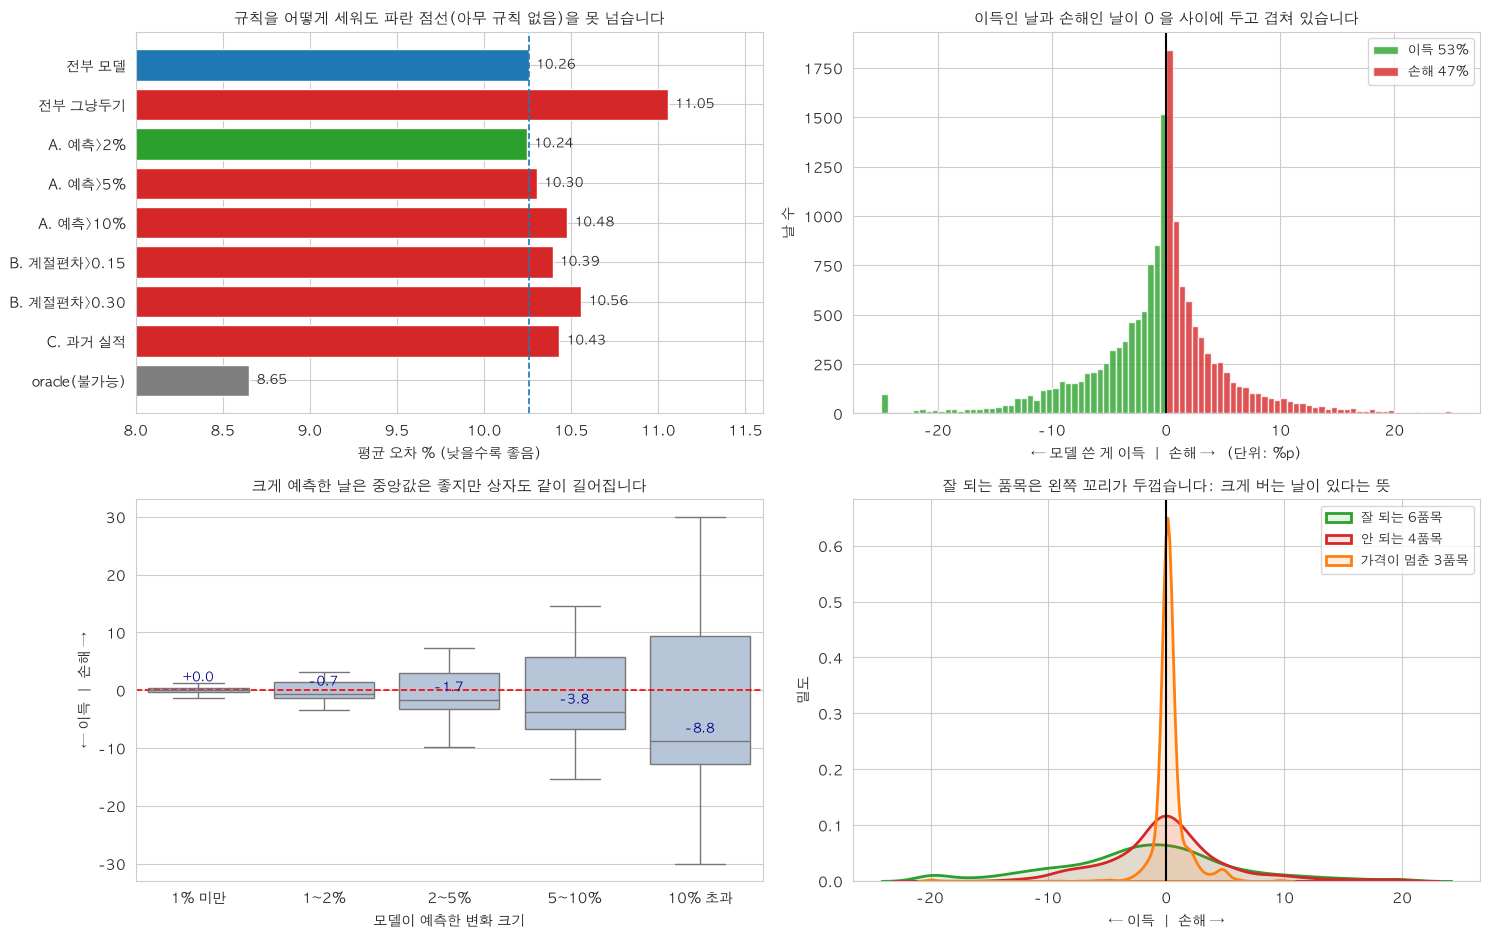

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))

# (1) 규칙별 성적
ax = axes[0, 0]
base = score.오차.iloc[0]
colors = ["tab:blue" if n == "전부 모델" else
          "tab:gray" if "oracle" in n else
          ("tab:green" if v < base else "tab:red")
          for n, v in zip(score.규칙, score.오차)]
ax.barh(score.규칙, score.오차, color=colors)
ax.axvline(base, color="tab:blue", ls="--", lw=1.2)
for i, v in enumerate(score.오차):
    ax.text(v + 0.04, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlim(8, 11.6)
ax.set_xlabel("평균 오차 % (낮을수록 좋음)")
ax.set_title("규칙을 어떻게 세워도 파란 점선(아무 규칙 없음)을 못 넘습니다", fontsize=11)
ax.invert_yaxis()

# (2) 이득/손해 분포
ax = axes[0, 1]
d = r.이득.clip(-25, 25)
ax.hist(d[d < 0], bins=45, color="tab:green", alpha=0.8,
        label=f"이득 {(r.이득 < 0).mean()*100:.0f}%")
ax.hist(d[d > 0], bins=45, color="tab:red", alpha=0.8,
        label=f"손해 {(r.이득 > 0).mean()*100:.0f}%")
ax.axvline(0, color="black", lw=1.5)
ax.set_xlabel("← 모델 쓴 게 이득  |  손해 →   (단위: %p)")
ax.set_ylabel("날 수")
ax.set_title("이득인 날과 손해인 날이 0 을 사이에 두고 겹쳐 있습니다", fontsize=11)
ax.legend(fontsize=9)

# (3) 예측 크기별
ax = axes[1, 0]
r2 = r.copy()
r2["예측 크기"] = pd.cut(r2.pred.abs(), [0, 0.01, 0.02, 0.05, 0.10, 1],
                      labels=["1% 미만", "1~2%", "2~5%", "5~10%", "10% 초과"])
sns.boxplot(data=r2, x="예측 크기", y=r2.이득.clip(-30, 30), ax=ax,
            showfliers=False, color="lightsteelblue")
ax.axhline(0, color="red", ls="--", lw=1.2)
med = r2.groupby("예측 크기", observed=True).이득.median()
for i, v in enumerate(med):
    ax.text(i, v + 1.5, f"{v:+.1f}", ha="center", fontsize=9,
            color="darkblue", weight="bold")
ax.set_ylabel("← 이득  |  손해 →")
ax.set_xlabel("모델이 예측한 변화 크기")
ax.set_title("크게 예측한 날은 중앙값은 좋지만 상자도 같이 길어집니다", fontsize=11)

# (4) 품목군별
ax = axes[1, 1]
WIN = ["시금치", "상추", "얼갈이배추", "미나리", "풋고추", "깻잎"]
FAIL = ["파", "무", "양배추", "감자"]
STALL = ["피마늘", "깐마늘(국산)", "생강"]
r3 = r.copy()
r3["군"] = np.where(r3.item.isin(WIN), "잘 되는 6품목",
            np.where(r3.item.isin(FAIL), "안 되는 4품목",
            np.where(r3.item.isin(STALL), "가격이 멈춘 3품목", "기타")))
for grp, c in (("잘 되는 6품목", "tab:green"), ("안 되는 4품목", "tab:red"),
               ("가격이 멈춘 3품목", "tab:orange")):
    sns.kdeplot(r3[r3.군 == grp].이득.clip(-20, 20), ax=ax, label=grp,
                color=c, lw=2, fill=True, alpha=0.12)
ax.axvline(0, color="black", lw=1.5)
ax.set_xlabel("← 이득  |  손해 →")
ax.set_ylabel("밀도")
ax.set_title("잘 되는 품목은 왼쪽 꼬리가 두껍습니다: 크게 버는 날이 있다는 뜻", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. 왜 안 되는가

규칙의 목표는 **손해인 날만 골라내 그냥 두기로 돌리는 것**입니다. 그러면 이득만
남습니다. oracle 이 바로 그걸 다 해냈을 때의 성적입니다.

문제는 **이득인 날과 손해인 날이 겉으로 구분되지 않는다**는 점입니다.

오른쪽 위 그림에서 초록(이득)과 빨강(손해)이 0 을 사이에 두고 거울처럼 겹쳐
있습니다. 어느 신호로 잘라도 둘이 같이 잘려 나갑니다.

왼쪽 아래가 그걸 구체적으로 보여줍니다. 모델이 크게 예측한 날일수록 중앙값은
확실히 좋아집니다. 그런데 **상자 자체가 같이 길어집니다**: 크게 버는 날이 늘어난
만큼 크게 잃는 날도 늘어서, 평균으로는 상쇄됩니다.

### 한 줄로 말하면

> **"오늘 모델이 맞을 날인가"를 아는 것이 "얼마나 오를까"를 아는 것만큼 어렵습니다.**

규칙을 세우려면 결국 또 하나의 예측 문제를 풀어야 하는데, 그게 원래 문제보다
쉽지 않습니다.

## 5. 결론

### 한 줄 요약

**시기로 나누는 것도 실패했습니다.** 어떤 규칙을 세워도 아무 규칙 없이 늘 모델을
쓰는 것보다 나아지지 않았습니다.

### 규칙별 성적

| 규칙 | 오차 | 모델 사용률 | 기준선 대비 |
|---|---|---|---|
| 전부 모델 (기준선) | 10.26 | 100% | — |
| A. 예측>2% | 10.24 | 57% | -0.01 |
| A. 예측>5% | 10.30 | 33% | +0.04 |
| B. 계절편차>0.15 | 10.39 | 45% | +0.14 |
| C. 과거 실적 | 10.43 | 69% | +0.18 |
| 전부 그냥두기 | 11.05 | 0% | +0.80 |
| **oracle (불가능)** | **8.65** | 53% | **-1.60** |

가장 나은 규칙이 -0.01 로, 08번에서 잰 노이즈 수준(±0.03)에도 못 미칩니다.

### 04번과 다른 점

04번(품목 단위 분기)은 **oracle 여지가 0.15 뿐**이라 "애초에 먹을 게 없었다"로
끝났습니다. 이번엔 **여지가 1.60 이나 되는데도 못 집었습니다.** 실패의 성격이
다릅니다: 없는 걸 못 잡은 게 아니라, 있는 걸 놓치고 있습니다.

### 왜 못 집는가

이득인 날과 손해인 날이 **겉으로 구분되지 않습니다.**

- 이득 52.9% · 손해 47.0% 로 거의 반반이고, 분포가 0 을 사이에 두고 겹칩니다
- 모델이 크게 예측한 날일수록 중앙값은 좋아집니다(1% 미만 +0.0 → 10% 초과 -8.8)
- 그런데 **분산도 같이 커집니다**: 크게 버는 날이 늘어난 만큼 크게 잃는 날도 늘어
  평균으로는 상쇄됩니다

### 시금치 9월이 알려준 것

모델이 크게 버는 구간은 **정교하게 맞혀서가 아닙니다.**

| 연도 | 실제 변화 | 모델 예측 | 방향 일치 |
|---|---|---|---|
| 2023 | -43.9% | -25.1% | 89% |
| 2024 | -31.6% | -23.0% | 94% |
| 2025 | -22.0% | -5.8% | 55% |

실제로 44% 떨어지는데 25% 만 예측해도, 0% 를 답하는 "그냥 두기"보다 훨씬
낫습니다. **큰 방향 하나를 맞히는 것**이 전부입니다. 실제와 예측의 상관은 0.177 로
오히려 낮습니다: 세부 등락은 전혀 못 맞힙니다.

반대로 파 8월은 모델이 매년 "오른다"고 답하는데 두 해가 내렸습니다. 방향 일치가
36~48% 로 동전 던지기보다 나쁩니다. 파는 8월 상대가격이 1.03 으로 평상시와 같아
**계절이 알려주는 게 없는데** 모델이 없는 패턴을 억지로 읽었습니다.

### 남는 것

이 실험은 실패했지만 쓸모 있는 사실 두 가지를 남깁니다.

1. **모델의 가치는 계절 전환기에 몰려 있습니다.** 진폭이 큰 품목이 잘 되는
   이유가 여기 있습니다: 크게 움직이는 구간에서 방향만 맞혀도 남습니다.
2. **그 구간을 미리 알아보는 표식이 지금 데이터에는 없습니다.** "오늘 모델이
   맞을 날인가"를 아는 것이 "얼마나 오를까"를 아는 것만큼 어렵습니다.

### 다음에 해볼 만한 것

- **목적을 바꾼다**: 지금은 평균 오차를 줄이는 게 목표인데, "큰 실수를 피한다"로
  바꾸면 규칙의 기준도 달라집니다. 분산이 문제라면 평균이 아니라 꼬리를 봐야
  합니다.
- **예측 대상을 바꾼다**: 가격 변화율 대신 **방향(오를까 내릴까)** 만 맞히는
  문제로 좁히면, 시금치 9월처럼 방향이 분명한 구간에서 더 잘 쓸 수 있습니다.
- **여기서 멈춘다**: 04·11번 모두 분기 규칙이 실패했습니다. 세 번째 시도 전에
  "분기로는 안 된다"를 결론으로 받아들일 수도 있습니다.
